In [1]:
import numpy as np
import glob, re, os

def find_folders(root, entropy_file):
    """Map N -> path of its entropy_file.txt file, from subfolders named N<N>."""
    folders = {}
    for path in glob.glob(os.path.join(root, "N*")):
        if not os.path.isdir(path):
            continue
        m = re.fullmatch(r"N(\d+)", os.path.basename(path))
        if not m:
            continue
        N = int(m.group(1))
        fpath = os.path.join(path, entropy_file)
        if os.path.isfile(fpath):
            folders[N] = fpath
    return dict(sorted(folders.items()))

def load_all_swap(root):
    files = find_folders(root,"entropy_swap.txt")
    if not files:
        raise FileNotFoundError(f"No N<N>/entropy_swap.txt files found under {root}")
    
    N_values = np.array(list(files.keys()))
    g_ref = None
    entropy = None
    error = None
    
    for i, N in enumerate(N_values):
        arr = np.loadtxt(files[N], comments='#')
        arr = arr[arr[:,0].argsort()]
        g, S, err = arr[:,0], arr[:,1], arr[:,2]
        
        if g_ref is None:
            g_ref = g
            entropy = np.full((len(N_values), len(g_ref)), np.nan)
            error   = np.full((len(N_values), len(g_ref)), np.nan)
        else:
            assert np.allclose(g, g_ref), f"g-grid mismatch in N={N}"
        
        entropy[i, :] = S
        error[i, :]   = err
    
    return N_values, g_ref, entropy, error

def load_all_Renyi(root):
    files = find_folders(root,"entropy_Renyi.txt")
    if not files:
        raise FileNotFoundError(f"No N<N>/entropy_Renyi.txt files found under {root}")
    
    N_values = np.array(list(files.keys()))
    g_ref = None
    entropy = None
    
    for i, N in enumerate(N_values):
        arr = np.loadtxt(files[N], comments='#')
        arr = arr[arr[:,0].argsort()]
        g, S = arr[:,0], arr[:,1]
        
        if g_ref is None:
            g_ref = g
            entropy = np.full((len(N_values), len(g_ref)), np.nan)
        else:
            assert np.allclose(g, g_ref), f"g-grid mismatch in N={N}"
        
        entropy[i, :] = S
    
    return N_values, g_ref, entropy

# def f(N, g, tol=1e-6):
#     """Return [entropy, error] for given N and g."""
#     i = np.searchsorted(N_values, N)
#     assert N_values[i] == N, f"N={N} not in dataset"
#     j = np.argmin(np.abs(g_values - g))
#     assert abs(g_values[j] - g) < tol, f"g={g} not on grid (closest {g_values[j]})"
#     return np.array([entropy[i, j], error[i, j]])

N_values, g_values, entropy_Renyi = load_all_Renyi('results/28may2026/')
N_values, g_values_duplicated, entropy_swap_duplicated, error_swap_duplicated = load_all_swap('results/28may2026/')
# The results are duplicated for the entropy swap
# Let's take the 2nd 
# entropy_swap = 0.5*(entropy_swap_duplicated[:,0::2]+entropy_swap_duplicated[:,1::2])
# error_swap = 0.5*(error_swap_duplicated[:,0::2]+error_swap_duplicated[:,1::2])
entropy_swap = 0.5*(entropy_swap_duplicated[:,1::2]+entropy_swap_duplicated[:,1::2])
error_swap = 0.5*(error_swap_duplicated[:,1::2]+error_swap_duplicated[:,1::2])

/tmp/ipykernel_36428/3325146198.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_36428/3325146198.py:69: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


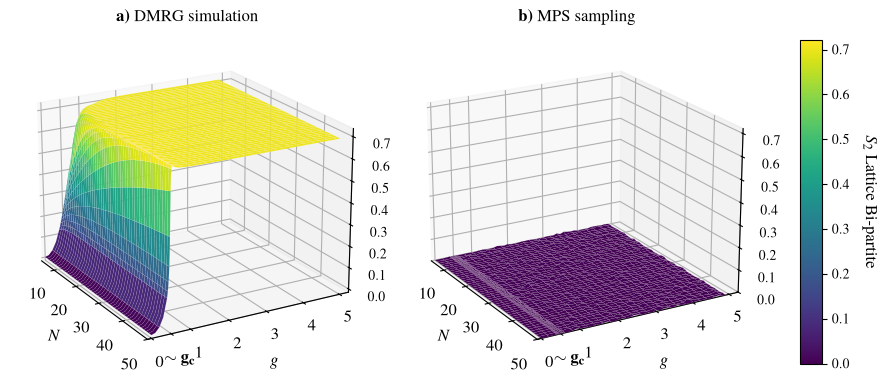

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# ---------- Plot 3: S(N,g) surface plot ----------
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'''
    \usepackage{nicefrac}
    \usepackage{siunitx}
    \usepackage{physics} 
    \usepackage[mathcal]{eucal}
    \DeclareFontFamily{OT1}{mathc}{}
    \DeclareFontShape{OT1}{mathc}{m}{it}{<-> mathc10}{}
    \DeclareMathAlphabet{\mathcal}{OT1}{mathc}{m}{it}
    '''
)
plt.rc('font', family='serif',serif='Times')
elev = 20
azim = -30
FontSize = 12
tickpad=1
LabelPad=2.5 #y axis
gc=0.5

fig = plt.figure(figsize=(12,7))
fig.subplots_adjust(wspace=0.1)
shared_cmap = "viridis"

gmax_idx = int(np.where(g_values == 5)[0][0])
G, Nn = np.meshgrid(g_values[:gmax_idx], N_values)  # shapes match entropy (n_N, n_g)
Z1 = entropy_Renyi[:,:gmax_idx]
Z2 = np.abs(entropy_swap[:,:gmax_idx]-entropy_Renyi[:,:gmax_idx])
x_min, x_max = Nn.min(), Nn.max()
y_min, y_max = G.min(), G.max()
z_min = min(Z1.min(), Z2.min())
z_max = max(Z1.max(), Z2.max())
shared_norm = Normalize(vmin=z_min, vmax=z_max)


ax1 = fig.add_subplot(1,2,1, projection='3d')
surf1 = ax1.plot_surface(Nn, G, Z1, lw=0.05, edgecolor='white', antialiased=True, cmap=shared_cmap, norm=shared_norm)
ax1.view_init(elev=elev, azim=azim)
ax1.set_title(r'\textbf{a)} DMRG simulation',fontsize=FontSize, pad=-20)



ax2 = fig.add_subplot(1,2,2, projection='3d')
surf2 = ax2.plot_surface(Nn, G, Z2, lw=0.05, edgecolor='white', antialiased=True, cmap=shared_cmap, norm=shared_norm)
ax2.view_init(elev=elev, azim=azim)
ax2.set_title(r'\textbf{b)} MPS sampling',fontsize=FontSize, pad=-20)

for ax in [ax1, ax2]:
    # ax.plot_surface(X, Y, Z, alpha=0.4, color='red', edgecolor='red')
    ax.set_xlim(xmin=N_values[0],xmax=N_values[-1])
    ax.set_ylim(ymin=-0.1)
    # ax.set_zlim(zmin=-0.01,zmax = 0.05)
    ax.set_xlabel(r'$N$',fontsize=FontSize)
    ax.set_ylabel(r'$g$',fontsize=FontSize)
    ax.set_yticks([0, gc, 1, 2,3,4,5])
    ax.set_yticklabels([0, r'$\mathbf{\sim g_c}$', 1, 2,3,4,5])
    ax.xaxis.set_tick_params(width=1, length=3, labelsize=FontSize)
    ax.yaxis.set_tick_params(width=1, length=3, labelsize=FontSize, pad=tickpad)
ax2.set_zlim(zmin=z_min,zmax=z_max)
# ax.set_zlabel(r"$S_2$",fontsize=FontSize)
# ax.set_title("S(N, g) surface")
cbar=fig.colorbar(surf1,ax=[ax1,ax2], shrink=0.6, aspect=15, pad=0.05, norm=shared_norm)
cbar.set_label(r"$S_2$ Lattice Bi-partite", size=FontSize, rotation=-90, labelpad=20)

plt.tight_layout()
plt.show()


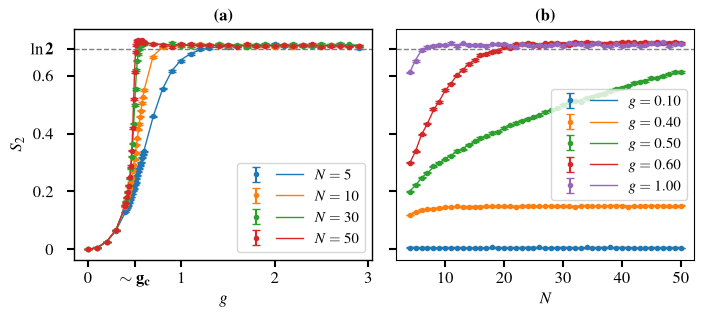

In [37]:

plt.rcParams["legend.handlelength"] = 4.0
from matplotlib.legend_handler import HandlerTuple
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8,3))
gs = gridspec.GridSpec(1, 2, wspace=0.08)
ax = fig.add_subplot(gs[0]),fig.add_subplot(gs[1])#,fig.add_subplot(gs[3])  # skip gs[2], the spacer

FontSize = 12
tickpad = 10

c=0
cmap = plt.colormaps['tab10']
k=0
gmax_idx = int(np.where(g_values == 3)[0][0])
pairs = []
labels = []
for n in [5,10,30,50]:
    i = int(np.where(N_values==n)[0][0])
    points = ax[c].errorbar(g_values[:gmax_idx] , entropy_swap[i,:gmax_idx], yerr=error_swap[i,:gmax_idx],ls=None, fmt='o', ms=3,capsize=3, color=cmap(k))
    lines, = ax[c].plot(g_values[:gmax_idx] , entropy_Renyi[i,:gmax_idx], ls='-', lw=1, color=cmap(k))
    pairs.append((points,lines))
    labels.append(r'$N=%i$'%n)
    k+=1
ax[c].axhline(np.log(2), lw=1, ls='--', color='grey')
ax[c].set_xlabel(r"$g$", fontsize=FontSize)
ax[c].set_ylabel(r"$S_2$", fontsize=FontSize)
# ax[c].legend(fontsize=FontSize)
ax[c].xaxis.set_tick_params(width=1.5, length=5, labelsize=FontSize)
ax[c].yaxis.set_tick_params(width=1.5, length=5, labelsize=FontSize, pad=tickpad)
ax[c].set_xticks([0, 0.5, 1, 2,3])
ax[c].set_xticklabels([0, r'$\mathbf{\sim g_c}$', 1, 2,3])
ax[c].set_yticks([0,.2,.4,.6, np.log(2)])
ax[c].set_yticklabels([0,.2,.4,.6,r'$\mathbf{\ln{2}}$'])
ax[c].legend(handles=pairs, labels=labels, handler_map={tuple: HandlerTuple(ndivide=None)},fontsize=0.9*FontSize)
ax[c].set_title( r"\bf(a)")
plt.setp(ax[c].spines.values(), linewidth=1)



c=1
cmap = plt.colormaps['tab10']
k=0
pairs = []
labels = []
for g in [0.1,0.4,0.5,0.6,1]:
    i = int(np.where(g_values==g)[0][0])
    points = ax[c].errorbar(N_values , entropy_swap[:,i], yerr=error_swap[:,i],ls=None, fmt='o', ms=3,capsize=3, color=cmap(k))
    lines, = ax[c].plot(N_values , entropy_Renyi[:,i], ls='-', lw=1, color=cmap(k))
    pairs.append((points,lines))
    labels.append(r'$g=%.2f$'%g)
    k+=1
ax[c].axhline(np.log(2), lw=1, ls='--', color='grey')
ax[c].set_xlabel(r"$N$", fontsize=FontSize)
ax[c].set_xticks([10,20,30,40,50])
ax[c].set_xticklabels([10,20,30,40,50])
ax[c].xaxis.set_tick_params(width=1.5, length=5, labelsize=FontSize)
ax[c].yaxis.set_tick_params(width=1.5, length=5, labelsize=FontSize, pad=tickpad)
ax[c].tick_params(labelleft=False)
ax[c].legend(handles=pairs, labels=labels, handler_map={tuple: HandlerTuple(ndivide=None)},fontsize=0.9*FontSize)
ax[c].sharey(ax[0])
ax[c].set_title( r"\bf(b)")

plt.savefig("S2(latt_bipartite)_DMRG_and_sampling.png",format = 'png', dpi=600)


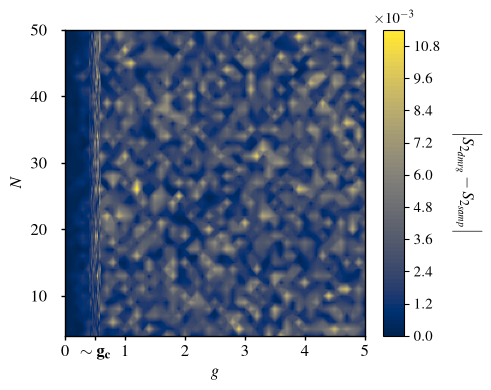

In [38]:

plt.rcParams["legend.handlelength"] = 4.0
from matplotlib.legend_handler import HandlerTuple
import matplotlib.gridspec as gridspec

fig,ax = plt.subplots(figsize=(5,4))
FontSize = 12
tickpad = 10

shared_cmap = "cividis"
G, Nn = np.meshgrid(g_values, N_values)  # shapes match entropy (n_N, n_g)
Z = np.abs(entropy_Renyi - entropy_swap)*1000
x_min, x_max = G.min(), G.max()
y_min, y_max = Nn.min(), Nn.max()
shared_norm = Normalize(vmin=Z.min(), vmax=Z.max())
contour = ax.contourf(G,Nn, Z, levels=100, cmap=shared_cmap, norm=shared_norm)
ax.set_ylabel(r'$N$',fontsize=FontSize)
ax.set_xlabel(r'$g$',fontsize=FontSize)
ax.set_xticks([0, gc, 1, 2,3,4,5])
ax.set_xticklabels([0, r'$\mathbf{\sim g_c}$', 1, 2,3,4,5])
ax.xaxis.set_tick_params(width=1, length=3, labelsize=FontSize)
ax.yaxis.set_tick_params(width=1, length=3, labelsize=FontSize, pad=tickpad)
cbar=fig.colorbar(contour, shrink=1, aspect=15, pad=0.05)
cbar.set_label(r"$\abs{S_{2_{dmrg}} - S_{2_{samp}}}$", size=FontSize, rotation=-90, labelpad=30)
cbar.formatter.set_scientific(False) 
cbar.update_ticks()
cbar.ax.set_title(r'$\times 10^{-3}$', fontsize=0.9*FontSize, pad=5)
cbar.ax.tick_params(labelsize=0.9*FontSize)
# cbar.formatter.set_powerlimits((-2, -2))
plt.setp(ax.spines.values(), linewidth=1)
plt.tight_layout()
plt.savefig("S2(latt_bipartite)_DMRG_vs_sampling.png",format = 'png', dpi=600)
